# SOS Baby Monitor — Training Notebook
**הוראות:**
1. העלי את תיקיית `data/raw` כ-zip (תא 2)
2. הריצי את כל התאים לפי הסדר
3. בסוף תורידי את `sos_model.keras` ו-`norm_stats.json` ותשמרי ב-`src/`

In [1]:
# ===== תא 1: התקנת ספריות =====
!pip install -q librosa soundfile

In [2]:
from google.colab import drive
import zipfile, os, glob

drive.mount('/content/drive')

# הורדה ישירה לפי File ID
import gdown
gdown.download(id='1bdx4CddFaf_Tzam0dO-_fD9U4KrFGxyR', output='/content/raw.zip', quiet=False)

print('📦 מחלץ...')
with zipfile.ZipFile('/content/raw.zip', 'r') as z:
    z.extractall('/content/data')
os.remove('/content/raw.zip')
print('✅ חילוץ הושלם')

# בדיקה
for cat in ['crying', 'background']:
    matches = glob.glob(f'/content/data/**/{cat}', recursive=True)
    if matches:
        print(f'✅ {cat}: {len(os.listdir(matches[0]))} קבצים')
    else:
        print(f'❌ WARNING: תיקיית {cat} לא נמצאה!')

RAW_CRYING     = glob.glob('/content/data/**/crying',     recursive=True)[0]
RAW_BACKGROUND = glob.glob('/content/data/**/background', recursive=True)[0]
RAW_DIR        = os.path.dirname(RAW_CRYING)
print(f'📂 RAW_DIR = {RAW_DIR}')


Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1bdx4CddFaf_Tzam0dO-_fD9U4KrFGxyR
From (redirected): https://drive.google.com/uc?id=1bdx4CddFaf_Tzam0dO-_fD9U4KrFGxyR&confirm=t&uuid=e97aed62-ef1c-4903-86db-ae719cc4ca5f
To: /content/raw.zip
100%|██████████| 764M/764M [00:14<00:00, 51.9MB/s]


📦 מחלץ...
✅ חילוץ הושלם
✅ crying: 1101 קבצים
✅ background: 1800 קבצים
📂 RAW_DIR = /content/data/raw


In [3]:
BG_DIR = RAW_BACKGROUND


In [4]:
# ===== תא 7: Preprocessing — קבצי שמע -> mel-spectrogram (numpy) =====

import numpy as np
import librosa
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = '/content/data/processed'
CATEGORIES    = ['crying', 'background']
CAT_DIRS      = {'crying': RAW_CRYING, 'background': BG_DIR}
SR            = 22050
DURATION      = 2.0
SUPPORTED     = ('.wav', '.3gp', '.mp3', '.ogg', '.flac', '.m4a')

os.makedirs(PROCESSED_DIR, exist_ok=True)

def process_file(file_path):
    audio, _ = librosa.load(file_path, sr=SR, duration=DURATION, mono=True)
    target_len = int(SR * DURATION)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128)
    return librosa.power_to_db(mel, ref=np.max)

total, errors = 0, 0

for category in CATEGORIES:
    cat_dir   = CAT_DIRS[category]
    all_files = [f for f in os.listdir(cat_dir) if f.lower().endswith(SUPPORTED)]
    cat_ok    = 0
    for filename in all_files:
        save_path = os.path.join(PROCESSED_DIR, f'{category}_{os.path.splitext(filename)[0]}.npy')
        if os.path.exists(save_path):
            cat_ok += 1
            continue
        try:
            mel = process_file(os.path.join(cat_dir, filename))
            np.save(save_path, mel)
            cat_ok += 1
        except Exception as e:
            errors += 1
    total += cat_ok
    print(f'{category}: {cat_ok} קבצים')

print(f'\n✅ סהכ: {total} | שגיאות: {errors}')

crying: 1101 קבצים
background: 1800 קבצים

✅ סהכ: 2901 | שגיאות: 0


In [5]:
# ===== תא 8: אימון המודל =====

import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

CATEGORIES    = ['crying', 'background']
PROCESSED_DIR = '/content/data/processed'

# טעינה
X, y = [], []
for label, category in enumerate(CATEGORIES):
    flist = [f for f in os.listdir(PROCESSED_DIR) if f.startswith(category)]
    for f in flist:
        X.append(np.load(os.path.join(PROCESSED_DIR, f)))
        y.append(label)

X = np.array(X)
print(f'crying: {y.count(0)} | background: {y.count(1)} | shape: {X.shape}')

# נרמול
mean = float(X.mean())
std  = float(X.std())
X    = (X - mean) / (std + 1e-8)
X    = X[..., np.newaxis]
print(f'נרמול: mean={mean:.2f}, std={std:.2f}')

y_cat = keras.utils.to_categorical(y, num_classes=2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# Augmentation
def augment(X_raw, y_raw):
    segs = [
        X_raw,
        X_raw + np.random.normal(0, 0.01, X_raw.shape),
        np.roll(X_raw, shift=10, axis=2),
        np.flip(X_raw, axis=2),
        X_raw * np.random.uniform(0.8, 1.2),
    ]
    return np.concatenate(segs), np.concatenate([y_raw] * 5)

X_train, y_train = augment(X_train, y_train)
print(f'אחרי augmentation: {len(X_train)} דוגמאות')

# מודל CNN
model = keras.Sequential([
    keras.layers.Input(shape=X.shape[1:]),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(2, activation='softmax'),
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# class weights
n_cry = float(np.sum(y_train[:, 0]))
n_bg  = float(np.sum(y_train[:, 1]))
total = float(len(y_train))
class_weight = {0: total / (2 * n_cry), 1: total / (2 * n_bg)}
print(f'class weights: crying={class_weight[0]:.2f}, background={class_weight[1]:.2f}')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight,
)

crying: 1101 | background: 1800 | shape: (2901, 128, 87)
נרמול: mean=-47.16, std=21.29
אחרי augmentation: 11600 דוגמאות


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 85, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,442 (427.51 KB)

 Trainable params: 109,442 (427.51 KB)

 Non-trainable params: 0 (0.00 B)

class weights: crying=1.32, background=0.81
Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 219s 598ms/step - accuracy: 0.8686 - loss: 0.3067 - val_accuracy: 0.9604 - val_loss: 0.1185
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 222s 613ms/step - accuracy: 0.9549 - loss: 0.1361 - val_accuracy: 0.9294 - val_loss: 0.2053
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 230s 632ms/step - accuracy: 0.9713 - loss: 0.0879 - val_accuracy: 0.9811 - val_loss: 0.0503
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 252s 606ms/step - accuracy: 0.9801 - loss: 0.0667 - val_accuracy: 0.9793 - val_loss: 0.0700
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 255s 585ms/step - accuracy: 0.9812 - loss: 0.0588 - val_accuracy: 0.9897 - val_loss: 0.0351
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 266s 598ms/step - accuracy: 0.9838 - loss: 0.0529 - val_accuracy: 0.9793 - val_loss: 0.0665
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 218s 600ms/step - accuracy: 0.9837 - loss: 0.0514 - val_accuracy: 0.9897 - val_loss: 0.0381
Epoch 8/50
363/363 ━━━━━━━━━━━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.9948 - loss: 0.0298

🎯 דיוק על Test set: 99.48%
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step


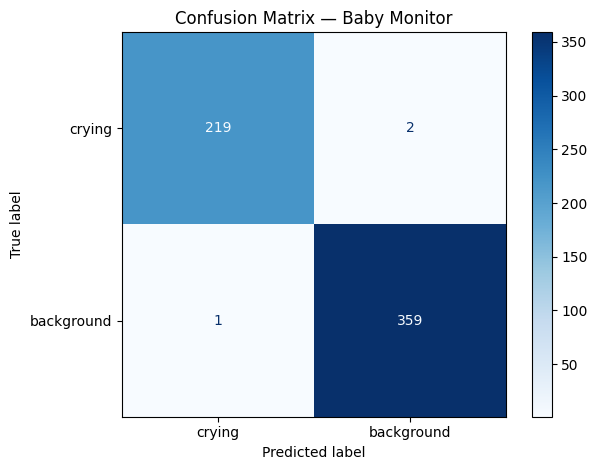

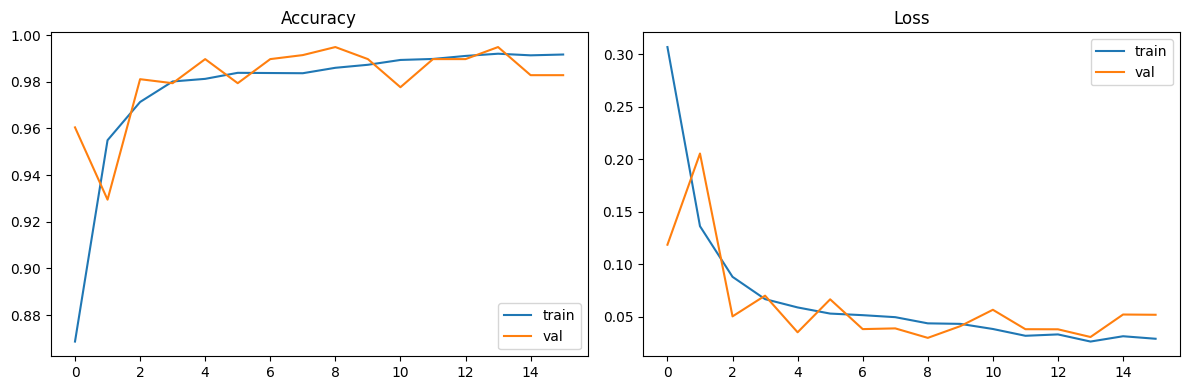

In [6]:
# ===== תא 9: הערכה + גרפים =====

loss, acc = model.evaluate(X_test, y_test)
print(f'\n🎯 דיוק על Test set: {acc:.2%}')

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Baby Monitor')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'],     label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],         label='train')
ax2.plot(history.history['val_loss'],     label='val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout()
plt.savefig('/content/training_history.png')
plt.show()

In [7]:
# ===== תא 10: שמירה והורדה =====

import json
from google.colab import files

model.save('/content/sos_model.keras')
with open('/content/norm_stats.json', 'w') as f:
    json.dump({'mean': mean, 'std': std}, f)

print('📥 מוריד קבצים...')
files.download('/content/sos_model.keras')
files.download('/content/norm_stats.json')
files.download('/content/confusion_matrix.png')
files.download('/content/training_history.png')
print('\n✅ סיום! שמרי את הקבצים ב-src/ של הפרויקט')

📥 מוריד קבצים...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ סיום! שמרי את הקבצים ב-src/ של הפרויקט


In [9]:
import os
print(os.path.exists('/content/sos_model.keras'))
print(os.path.getsize('/content/sos_model.keras') if os.path.exists('/content/sos_model.keras') else 'לא קיים')


True
1358633


In [11]:
from google.colab import files
files.download('/content/sos_model.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>